# Q4: 什么时候买卖？

Q3 我们用风险平价策略解决了"买多少"——波动大的少买，波动小的多买，让每只 ETF 承担相同的风险。

但有个细节你可能没注意：策略每 10 个交易日自动调一次仓。为什么是 10 天？5 天行不行？一个月呢？

更关键的问题是：**如果在两次调仓之间，某只 ETF 突然暴跌 20%，你只能干等到下一个调仓日才能反应。** 这合理吗？

### 路线图

**选什么标的（Q2 ✓）→ 每个买多少（Q3 ✓）→ 什么时候买卖（Q4）→ 怎么验证有效（Q5）**

本章解决第三步。分三个小步回答：**调仓频率怎么选 → 亏了要不要跑 → 赚了要不要走**

铁律不变：**先猜后验，数据说了算。**

### 前置条件

- 已完成 Q3
- 已安装 open-xquant：`pip install open-xquant[yfinance]`

### 操作方式

和前面一样：阅读说明 → 打开对应 spec → 复制到 TRAE → 观察结果 → 回来看解读。

---

## Step 1: 调仓频率有多重要？

Q3 每 10 个交易日调一次仓——这个“10”是拍脑袋定的。调得更勤（每周）会更好吗？调得更懒（每季度）会更差吗？

直觉告诉我们：调得越勤，反应越快，效果应该越好。真的吗？

👉 **打开 `specs/spec-01-rebalance-frequency.md`，复制到 TRAE。**

数据加载完成
  沪深300ETF: 1250 个交易日
  纳指100ETF: 1251 个交易日
  黄金ETF: 1250 个交易日

调仓频率对比（不含交易成本）
    频率      累计收益率      年化波动率       最大回撤       夏普比率       交易次数
------------------------------------------------------------------------
     5     99.34%     10.96%    -12.55%       1.33        737
    10    103.00%     11.15%    -12.42%       1.34        369
    21     99.87%     11.45%    -14.40%       1.28        177
    63    106.46%     11.96%    -14.61%       1.29         57

调仓频率对比（含交易成本：万一佣金 + 5元最低）
    频率      累计收益率      年化波动率       最大回撤       夏普比率       交易次数       总手续费
----------------------------------------------------------------------------------
     5     91.53%     10.96%    -13.39%       1.25        738       4636
    10     98.01%     11.16%    -12.81%       1.29        369       2957
    21     96.68%     11.46%    -14.55%       1.25        177       1982
    63    105.03%     11.97%    -14.66%       1.27         57        899


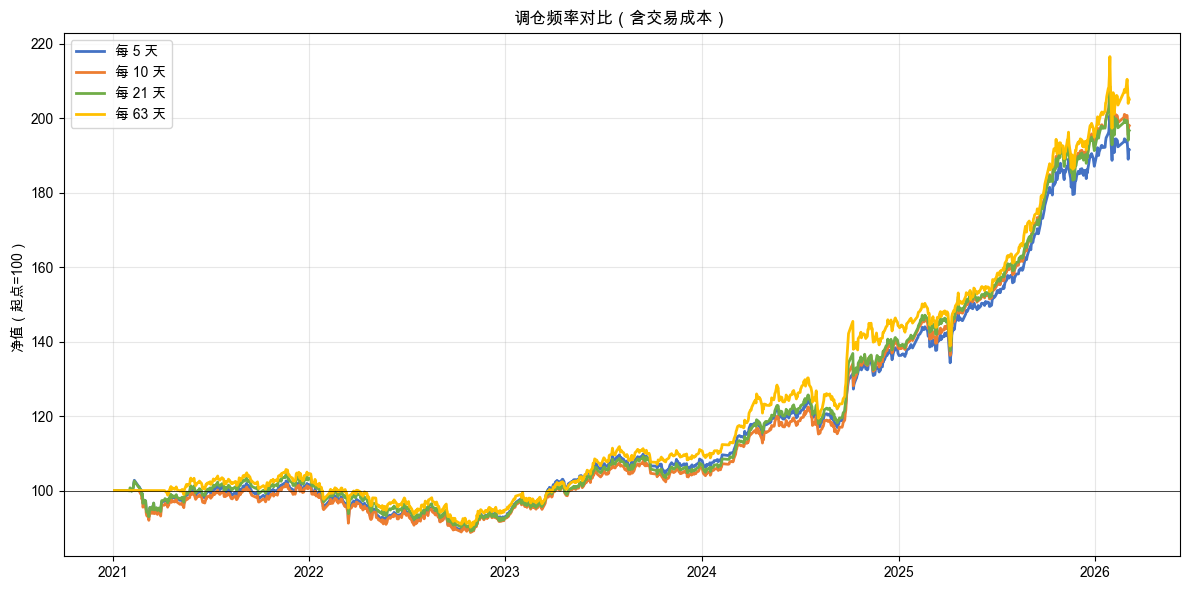


不含成本时，每 10 天调仓的夏普比率最高（1.34）。
加上成本后，每 10 天调仓的夏普比率最高（1.29）。
排名没变，但成本拉开了差距。

交易次数：频率 5 → 738 笔，频率 63 → 57 笔。
总手续费：频率 5 → 4636 元，频率 63 → 899 元。

每次调仓都不是免费的——佣金和手续费是实打实的钱。频率越高，交易越多，成本越大。
但频率的选择不是最关键的问题。更要命的是——两次调仓之间如果某只 ETF 暴跌，你只能干等到下一个调仓日。能不能加一个'紧急出口'？


In [2]:
from oxq.core import Engine, Strategy
from oxq.data import YFinanceDownloader, LocalMarketDataProvider
from oxq.indicators import RollingVolatility
from oxq.signals import RiskParity
from oxq.rules import RebalanceRule
from oxq.trade import SimBroker, PercentageFee
from oxq.universe import StaticUniverse
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from decimal import Decimal

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'STHeiti']
plt.rcParams['axes.unicode_minus'] = False

# ── 常量 ──
SYMBOLS = ("510300.SS", "513100.SS", "518880.SS")
SYMBOL_NAMES = {
    "510300.SS": "沪深300ETF",
    "513100.SS": "纳指100ETF",
    "518880.SS": "黄金ETF",
}
START = "2021-01-01"
today = pd.Timestamp.now().strftime("%Y-%m-%d")
FREQUENCIES = [5, 10, 21, 63]
FEE_MODEL = PercentageFee(rate=Decimal("0.001"), min_fee=Decimal("5"))

# ── 下载数据 ──
downloader = YFinanceDownloader()
for sym in SYMBOLS:
    downloader.download(sym, start=START, end=today)

# ── 构建投资宇宙 + 加载数据 + 预计算指标 ──
universe = StaticUniverse(symbols=SYMBOLS, name="global-macro-etf")
market = LocalMarketDataProvider()
mktdata = {}
for sym in SYMBOLS:
    d = market.get_bars(sym, START, today).copy()
    d["vol"] = RollingVolatility().compute(d, column="close", period=20)
    mktdata[sym] = d

print("数据加载完成")
for sym in SYMBOLS:
    print(f"  {SYMBOL_NAMES[sym]}: {len(mktdata[sym])} 个交易日")

# ── 公共策略配置 ──
COMMON = dict(
    universe=universe,
    indicators={"vol": (RollingVolatility(), {"column": "close", "period": 20})},
    signals={"tw": (RiskParity(), {"vol": "vol"})},
    entry_rules=[],
    exit_rules=[],
)

# ── 共同交易日（消除中美日历差异） ──
common_trading_days = mktdata[SYMBOLS[0]].index
for sym in SYMBOLS[1:]:
    common_trading_days = common_trading_days.intersection(mktdata[sym].index)

# ── 回测函数 ──
def run_backtest(frequency, fee_model=None):
    strategy = Strategy(
        name=f"freq-{frequency}",
        rebalance_rules=[RebalanceRule(weight_col="tw", frequency=frequency)],
        **COMMON,
    )
    broker = SimBroker(fee_model=fee_model) if fee_model else SimBroker()
    result = Engine().run(
        strategy,
        market=LocalMarketDataProvider(),
        broker=broker,
        start=START,
        end=today,
    )
    return result

# ══════════════════════════════════════════════
# 第一轮：不含成本
# ══════════════════════════════════════════════
results_no_fee = {}
for freq in FREQUENCIES:
    results_no_fee[freq] = run_backtest(freq, fee_model=None)

print("\n调仓频率对比（不含交易成本）")
print("=" * 72)
print(f"{'频率':>6} {'累计收益率':>10} {'年化波动率':>10} {'最大回撤':>10} {'夏普比率':>10} {'交易次数':>10}")
print("-" * 72)
for freq in FREQUENCIES:
    r = results_no_fee[freq]
    print(f"{freq:>6} {r.total_return():>10.2%} {r.annualized_volatility():>10.2%} "
          f"{r.max_drawdown():>10.2%} {r.sharpe_ratio():>10.2f} {len(r.trades):>10}")

# ══════════════════════════════════════════════
# 第二轮：含成本
# ══════════════════════════════════════════════
results_with_fee = {}
for freq in FREQUENCIES:
    results_with_fee[freq] = run_backtest(freq, fee_model=FEE_MODEL)

print("\n调仓频率对比（含交易成本：万一佣金 + 5元最低）")
print("=" * 82)
print(f"{'频率':>6} {'累计收益率':>10} {'年化波动率':>10} {'最大回撤':>10} {'夏普比率':>10} {'交易次数':>10} {'总手续费':>10}")
print("-" * 82)
for freq in FREQUENCIES:
    r = results_with_fee[freq]
    total_fee = sum(float(f.fee) for f in r.trades)
    print(f"{freq:>6} {r.total_return():>10.2%} {r.annualized_volatility():>10.2%} "
          f"{r.max_drawdown():>10.2%} {r.sharpe_ratio():>10.2f} {len(r.trades):>10} {total_fee:>10.0f}")

# ── 净值曲线对比（含成本） ──
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#4472C4', '#ED7D31', '#70AD47', '#FFC000']
for i, freq in enumerate(FREQUENCIES):
    equity = pd.Series(dict(results_with_fee[freq].equity_curve))
    equity = equity.reindex(common_trading_days).dropna()
    norm = equity / equity.iloc[0] * 100
    ax.plot(norm.index, norm.values, label=f'每 {freq} 天', color=colors[i], linewidth=2)

ax.axhline(y=100, color='black', linestyle='-', linewidth=0.5)
ax.set_ylabel('净值（起点=100）')
ax.set_title('调仓频率对比（含交易成本）')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── 分析 ──
# 无成本最优
best_no_fee = max(FREQUENCIES, key=lambda f: results_no_fee[f].sharpe_ratio())
# 含成本最优
best_with_fee = max(FREQUENCIES, key=lambda f: results_with_fee[f].sharpe_ratio())

print(f"\n不含成本时，每 {best_no_fee} 天调仓的夏普比率最高（{results_no_fee[best_no_fee].sharpe_ratio():.2f}）。")
print(f"加上成本后，每 {best_with_fee} 天调仓的夏普比率最高（{results_with_fee[best_with_fee].sharpe_ratio():.2f}）。")
if best_no_fee != best_with_fee:
    print(f"排名变了！成本改变了最优频率的选择。")
else:
    print(f"排名没变，但成本拉开了差距。")

fees = {freq: sum(float(f.fee) for f in results_with_fee[freq].trades) for freq in FREQUENCIES}
print(f"\n交易次数：频率 {FREQUENCIES[0]} → {len(results_with_fee[FREQUENCIES[0]].trades)} 笔，"
      f"频率 {FREQUENCIES[-1]} → {len(results_with_fee[FREQUENCIES[-1]].trades)} 笔。")
print(f"总手续费：频率 {FREQUENCIES[0]} → {fees[FREQUENCIES[0]]:.0f} 元，"
      f"频率 {FREQUENCIES[-1]} → {fees[FREQUENCIES[-1]]:.0f} 元。")

print(f"\n每次调仓都不是免费的——佣金和手续费是实打实的钱。频率越高，交易越多，成本越大。")
print(f"但频率的选择不是最关键的问题。更要命的是——两次调仓之间如果某只 ETF 暴跌，你只能干等到下一个调仓日。能不能加一个'紧急出口'？")

### Step 1 解读

频率有影响，但不是最关键的发现。更重要的是我们第一次看到了**交易成本**的力量。

每次调仓——不管是买还是卖——都要付佣金。频率越高，交易越多，成本越大。在不含成本的"理想世界"里看起来不错的策略，加上成本后可能完全变了样。

**数据说了算：频率的选择是个权衡——反应速度 vs 交易成本。**

但频率不是最大的问题。想象一下：你刚调完仓，第二天某只 ETF 暴跌 15%。下一次调仓要等好几天——这段时间你只能眼睁睁看着亏损扩大。

能不能加一个"紧急出口"——不管调仓日到没到，亏到一定程度就先跑？

---

## Step 2: 亏了能不能先跑？

定期调仓的硬伤很明显：两次调仓之间如果市场暴跌，你只能干等。

直觉告诉我们：亏了先跑，总比死抗好。但“跑”也不是免费的——每次卖出再买回来，都要付手续费。

到底值不值？先猜后验。

👉 **打开 `specs/spec-02-stop-loss.md`，复制到 TRAE。**

StopLossRule 工作原理
当你持有某只 ETF 时，StopLossRule 会自动做一件事：
  以 买入均价 x (1 - threshold) 为止损价，
  向 SimBroker 提交一个 stop SELL 挂单。

SimBroker 每天检查：收盘价跌破止损价了吗？
  跌破了 → 自动卖出
  没跌破 → 继续持有

这和 Signal 有本质区别：
  Signal 只看市场数据（动量、波动率），不知道你买了多少钱。
  Rule 看持仓状态——知道你的买入价和亏损程度。
  止损这件事，只有 Rule 能做。

基准频率：每 10 天（Step 1 含成本最优）

止损规则对比（频率=10天，含交易成本）
    止损阈值      累计收益率      年化波动率       最大回撤       夏普比率       交易次数       总手续费
----------------------------------------------------------------------------------------
     无止损     98.01%     11.16%    -12.81%       1.29        369       2957
      5%    106.23%     10.61%    -13.07%       1.43        387       3861
     10%    106.16%     10.86%    -12.02%       1.40        375       3278
     15%     99.30%     11.02%    -12.51%       1.32        371       3066


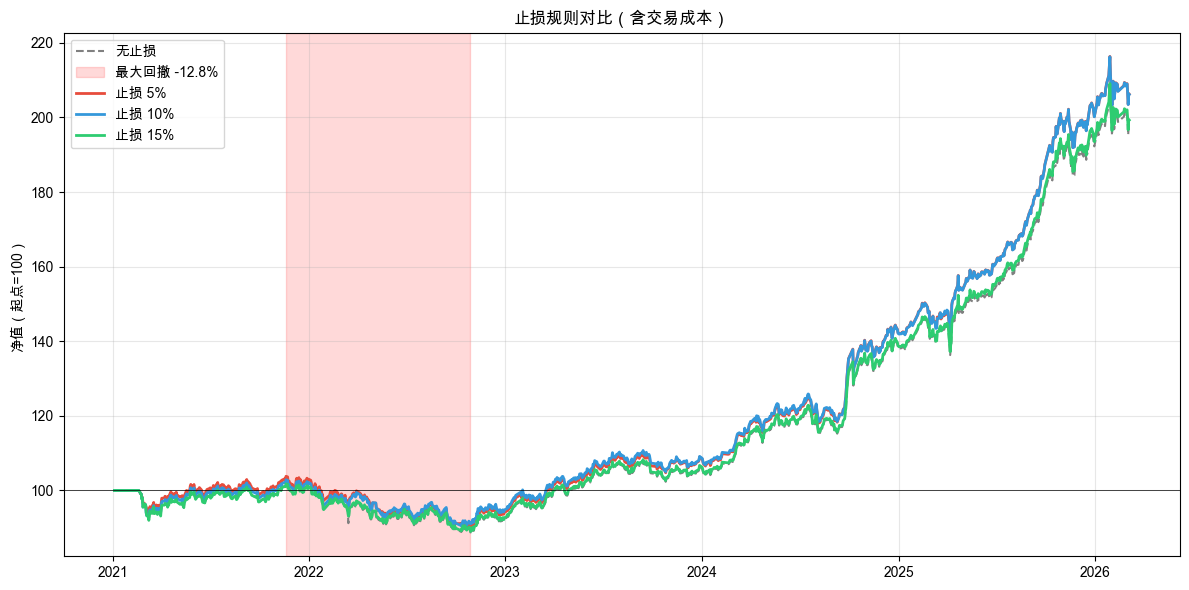


无止损的最大回撤：-12.81%
止损 5%：最大回撤加深到 -13.07%，多了 18 笔交易，多花 905 元手续费
止损 10%：最大回撤收窄到 -12.02%，多了 6 笔交易，多花 322 元手续费
止损 15%：最大回撤收窄到 -12.51%，多了 2 笔交易，多花 109 元手续费

止损不是免费的——每次止损都是一次额外的卖出+之后的买回，都要付手续费。
止损保护了本金——'活着才能赚钱'。但阈值怎么选，是个权衡。


In [3]:
from oxq.rules import StopLossRule

# ── StopLossRule 工作原理 ──
print("StopLossRule 工作原理")
print("=" * 60)
print("当你持有某只 ETF 时，StopLossRule 会自动做一件事：")
print("  以 买入均价 x (1 - threshold) 为止损价，")
print("  向 SimBroker 提交一个 stop SELL 挂单。")
print()
print("SimBroker 每天检查：收盘价跌破止损价了吗？")
print("  跌破了 → 自动卖出")
print("  没跌破 → 继续持有")
print()
print("这和 Signal 有本质区别：")
print("  Signal 只看市场数据（动量、波动率），不知道你买了多少钱。")
print("  Rule 看持仓状态——知道你的买入价和亏损程度。")
print("  止损这件事，只有 Rule 能做。")

# ── 基准频率（取 Step 1 含成本最优） ──
BEST_FREQ = max(FREQUENCIES, key=lambda f: results_with_fee[f].sharpe_ratio())
print(f"\n基准频率：每 {BEST_FREQ} 天（Step 1 含成本最优）")

# ── 止损阈值 ──
STOP_THRESHOLDS = [None, 0.05, 0.10, 0.15]

# ── 回测 ──
results_sl = {}
for sl in STOP_THRESHOLDS:
    order_rules = [StopLossRule(threshold=sl)] if sl is not None else []
    strategy = Strategy(
        name=f"sl-{sl}",
        rebalance_rules=[RebalanceRule(weight_col="tw", frequency=BEST_FREQ)],
        order_rules=order_rules,
        **COMMON,
    )
    broker = SimBroker(fee_model=FEE_MODEL)
    result = Engine().run(
        strategy,
        market=LocalMarketDataProvider(),
        broker=broker,
        start=START,
        end=today,
    )
    results_sl[sl] = result

# ── 对比表 ──
print(f"\n止损规则对比（频率={BEST_FREQ}天，含交易成本）")
print("=" * 88)
print(f"{'止损阈值':>8} {'累计收益率':>10} {'年化波动率':>10} {'最大回撤':>10} {'夏普比率':>10} {'交易次数':>10} {'总手续费':>10}")
print("-" * 88)
for sl in STOP_THRESHOLDS:
    r = results_sl[sl]
    label = "无止损" if sl is None else f"{sl:.0%}"
    total_fee = sum(float(f.fee) for f in r.trades)
    print(f"{label:>8} {r.total_return():>10.2%} {r.annualized_volatility():>10.2%} "
          f"{r.max_drawdown():>10.2%} {r.sharpe_ratio():>10.2f} {len(r.trades):>10} {total_fee:>10.0f}")

# ── 净值曲线对比 + 最大回撤标注 ──
fig, ax = plt.subplots(figsize=(12, 6))

# 无止损（灰色虚线）+ 标注最大回撤
equity_base = pd.Series(dict(results_sl[None].equity_curve))
equity_base = equity_base.reindex(common_trading_days).dropna()
norm_base = equity_base / equity_base.iloc[0] * 100
ax.plot(norm_base.index, norm_base.values, label='无止损', linestyle='--', color='gray', linewidth=1.5)

# 标注最大回撤时段（浅红色阴影）
cummax = norm_base.cummax()
drawdown = (norm_base - cummax) / cummax
dd_end = drawdown.idxmin()
dd_start = norm_base.loc[:dd_end].idxmax()
ax.axvspan(dd_start, dd_end, alpha=0.15, color='red', label=f'最大回撤 {drawdown.min():.1%}')

# 3 种止损阈值（彩色实线）
sl_colors = ['#E74C3C', '#3498DB', '#2ECC71']
for i, sl in enumerate([0.05, 0.10, 0.15]):
    equity = pd.Series(dict(results_sl[sl].equity_curve))
    equity = equity.reindex(common_trading_days).dropna()
    norm = equity / equity.iloc[0] * 100
    ax.plot(norm.index, norm.values, label=f'止损 {sl:.0%}', color=sl_colors[i], linewidth=2)

ax.axhline(y=100, color='black', linestyle='-', linewidth=0.5)
ax.set_ylabel('净值（起点=100）')
ax.set_title('止损规则对比（含交易成本）')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── 分析 ──
base_dd = results_sl[None].max_drawdown()
base_trades = len(results_sl[None].trades)
base_fee = sum(float(f.fee) for f in results_sl[None].trades)

print(f"\n无止损的最大回撤：{base_dd:.2%}")
for sl in [0.05, 0.10, 0.15]:
    r = results_sl[sl]
    dd = r.max_drawdown()
    trades = len(r.trades)
    fee = sum(float(f.fee) for f in r.trades)
    dd_change = "收窄" if dd > base_dd else "加深"
    print(f"止损 {sl:.0%}：最大回撤{dd_change}到 {dd:.2%}，"
          f"多了 {trades - base_trades} 笔交易，多花 {fee - base_fee:.0f} 元手续费")

print(f"\n止损不是免费的——每次止损都是一次额外的卖出+之后的买回，都要付手续费。")
print(f"止损保护了本金——'活着才能赚钱'。但阈值怎么选，是个权衡。")

### Step 2 解读

止损规则和之前用过的信号（Signal）有一个根本区别：**信号只看市场数据，止损看的是你的持仓。**

Q3 的风险平价信号在计算权重时，只关心"过去 20 天这只 ETF 的波动有多大"。它不知道你什么时候买的、买了多少钱、现在是赚还是亏。

止损规则不同——它需要知道"我的买入价是多少，从买入价跌了百分之几"。这种对持仓状态的感知，是 Signal 做不到的，只有 Rule 能做。

#### 为什么 5% 止损的最大回撤反而更大？

你可能注意到一个反直觉的现象：5% 止损的最大回撤比不止损还略大。这不是 bug，而是止损在**慢熊市**中的副作用——**锯齿效应**。

2022 年市场持续阴跌，5% 止损反复触发，形成一个循环：

```
持仓 → 跌 5% 触发止损卖出（亏损 + 手续费）
     → 调仓日买回来（手续费）
     → 继续跌 5% 又触发止损（亏损 + 手续费）
     → 调仓日又买回来……
```

每一轮"卖-买"付两笔手续费，但并没有真正躲开下跌——因为买回来之后市场继续跌。止损只是让你"分批亏"而非"一次亏到底"，额外的交易成本累积起来，反而让总回撤略微加深。

**止损对"急跌"有效（一跌到位就跑），对"慢熊"有害（反复割肉又买回来）。阈值太紧，在慢熊市中会被反复收割。**

**数据说了算：止损保护了本金——"活着才能赚钱"。但阈值怎么选，是个权衡。**

---

## Step 3: 赚了要不要走？

止损帮你控制了亏损。但反过来想：赚了一定程度，要不要主动卖掉、落袋为安？万一涨上去又跌回来，岂不是白赚一场？

直觉告诉我们：赚了就走，锁定利润，总比看着利润蒸发好。

真的吗？先猜后验。

👉 **打开 `specs/spec-03-take-profit.md`，复制到 TRAE。**

TakeProfitRule 工作原理
和止损类似，当你持有某只 ETF 时，TakeProfitRule 会：
  以 买入均价 x (1 + threshold) 为止盈价，
  向 SimBroker 提交一个 limit SELL 挂单。

SimBroker 每天检查：收盘价涨到止盈价了吗？
  涨到了 → 自动卖出，锁定利润
  没涨到 → 继续持有

基准配置：频率 10 天 + 止损 5%（Step 2 最优）

止盈规则对比（频率=10天，止损=5%，含交易成本）
    止盈阈值      累计收益率      年化波动率       最大回撤       夏普比率       交易次数       总手续费
----------------------------------------------------------------------------------------
     不止盈    106.23%     10.61%    -13.07%       1.43        387       3861
     10%     68.96%      9.21%     -9.82%       1.19        438       6905
     20%     90.74%      9.79%    -11.14%       1.38        408       5308
     30%    104.72%     10.02%    -13.07%       1.49        397       4365


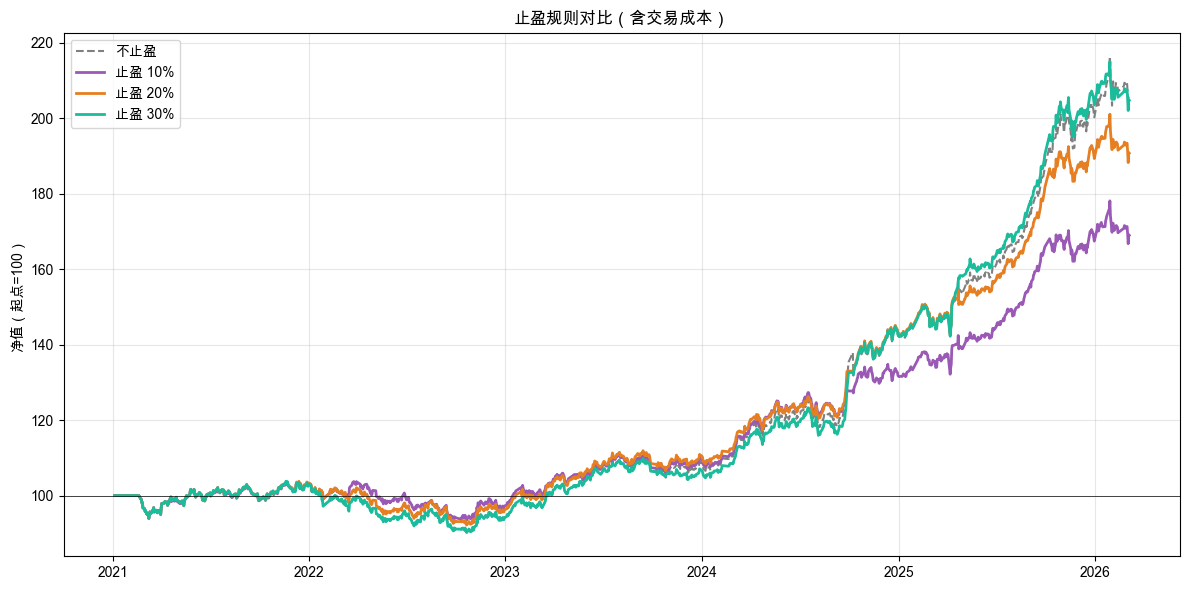


交易记录（止盈 10%，前 10 笔）
日期           标的             方向           数量        成交价 订单类型            手续费
--------------------------------------------------------------------------------
2021-02-19 00:00:00 沪深300ETF       BUY        5738     5.2435 market        30.09
2021-02-19 00:00:00 纳指100ETF       BUY       29981     0.9054 market        27.14
2021-02-19 00:00:00 黄金ETF          BUY       11768     3.6340 market        42.76
2021-02-24 00:00:00 沪深300ETF       SELL       5738     4.9813 stop          28.58
2021-02-26 00:00:00 纳指100ETF       SELL      29981     0.8601 stop          25.79
2021-03-05 00:00:00 沪深300ETF       BUY        5383     4.7640 market        25.64
2021-03-05 00:00:00 纳指100ETF       BUY       31672     0.8364 market        26.49
2021-03-05 00:00:00 黄金ETF          BUY         597     3.4820 market         5.00
2021-03-09 00:00:00 沪深300ETF       SELL       5383     4.5258 stop          24.36
2021-03-19 00:00:00 沪深300ETF       BUY        5191     4.5207 market        23.47

不止

In [4]:
from oxq.rules import TakeProfitRule

# ── TakeProfitRule 工作原理 ──
print("TakeProfitRule 工作原理")
print("=" * 60)
print("和止损类似，当你持有某只 ETF 时，TakeProfitRule 会：")
print("  以 买入均价 x (1 + threshold) 为止盈价，")
print("  向 SimBroker 提交一个 limit SELL 挂单。")
print()
print("SimBroker 每天检查：收盘价涨到止盈价了吗？")
print("  涨到了 → 自动卖出，锁定利润")
print("  没涨到 → 继续持有")

# ── 最优止损（取 Step 2 夏普最高的阈值） ──
sl_options = [sl for sl in STOP_THRESHOLDS if sl is not None]
BEST_SL = max(sl_options, key=lambda sl: results_sl[sl].sharpe_ratio())
print(f"\n基准配置：频率 {BEST_FREQ} 天 + 止损 {BEST_SL:.0%}（Step 2 最优）")

# ── 止盈阈值 ──
TP_THRESHOLDS = [None, 0.10, 0.20, 0.30]

# ── 回测 ──
results_tp = {}
for tp in TP_THRESHOLDS:
    order_rules = [StopLossRule(threshold=BEST_SL)]
    if tp is not None:
        order_rules.append(TakeProfitRule(threshold=tp))
    strategy = Strategy(
        name=f"tp-{tp}",
        rebalance_rules=[RebalanceRule(weight_col="tw", frequency=BEST_FREQ)],
        order_rules=order_rules,
        **COMMON,
    )
    broker = SimBroker(fee_model=FEE_MODEL)
    result = Engine().run(
        strategy,
        market=LocalMarketDataProvider(),
        broker=broker,
        start=START,
        end=today,
    )
    results_tp[tp] = result

# ── 对比表 ──
print(f"\n止盈规则对比（频率={BEST_FREQ}天，止损={BEST_SL:.0%}，含交易成本）")
print("=" * 88)
print(f"{'止盈阈值':>8} {'累计收益率':>10} {'年化波动率':>10} {'最大回撤':>10} {'夏普比率':>10} {'交易次数':>10} {'总手续费':>10}")
print("-" * 88)
for tp in TP_THRESHOLDS:
    r = results_tp[tp]
    label = "不止盈" if tp is None else f"{tp:.0%}"
    total_fee = sum(float(f.fee) for f in r.trades)
    print(f"{label:>8} {r.total_return():>10.2%} {r.annualized_volatility():>10.2%} "
          f"{r.max_drawdown():>10.2%} {r.sharpe_ratio():>10.2f} {len(r.trades):>10} {total_fee:>10.0f}")

# ── 净值曲线对比 ──
fig, ax = plt.subplots(figsize=(12, 6))

# 不止盈（灰色虚线）
equity_base = pd.Series(dict(results_tp[None].equity_curve))
equity_base = equity_base.reindex(common_trading_days).dropna()
norm_base = equity_base / equity_base.iloc[0] * 100
ax.plot(norm_base.index, norm_base.values, label='不止盈', linestyle='--', color='gray', linewidth=1.5)

# 3 种止盈阈值（彩色实线）
tp_colors = ['#9B59B6', '#E67E22', '#1ABC9C']
for i, tp in enumerate([0.10, 0.20, 0.30]):
    equity = pd.Series(dict(results_tp[tp].equity_curve))
    equity = equity.reindex(common_trading_days).dropna()
    norm = equity / equity.iloc[0] * 100
    ax.plot(norm.index, norm.values, label=f'止盈 {tp:.0%}', color=tp_colors[i], linewidth=2)

ax.axhline(y=100, color='black', linestyle='-', linewidth=0.5)
ax.set_ylabel('净值（起点=100）')
ax.set_title('止盈规则对比（含交易成本）')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── 交易记录（止盈阈值最小那组，前 10 笔） ──
smallest_tp = min(tp for tp in TP_THRESHOLDS if tp is not None)
trades = results_tp[smallest_tp].trades
print(f"\n交易记录（止盈 {smallest_tp:.0%}，前 10 笔）")
print("=" * 80)
print(f"{'日期':<12} {'标的':<14} {'方向':<6} {'数量':>8} {'成交价':>10} {'订单类型':<10} {'手续费':>8}")
print("-" * 80)
for t in trades[:10]:
    sym_name = SYMBOL_NAMES.get(t.order.symbol, t.order.symbol)
    print(f"{t.filled_at:<12} {sym_name:<14} {t.order.side:<6} {t.order.shares:>8} "
          f"{float(t.filled_price):>10.4f} {t.order.order_type:<10} {float(t.fee):>8.2f}")

# ── 分析 ──
base_ret = results_tp[None].total_return()
base_sharpe = results_tp[None].sharpe_ratio()
print(f"\n不止盈的累计收益率：{base_ret:.2%}，夏普比率：{base_sharpe:.2f}")
for tp in [0.10, 0.20, 0.30]:
    r = results_tp[tp]
    ret = r.total_return()
    sharpe = r.sharpe_ratio()
    ret_dir = "提高" if ret > base_ret else "降低"
    sharpe_dir = "提高" if sharpe > base_sharpe else "降低"
    print(f"止盈 {tp:.0%}：收益率{ret_dir}到 {ret:.2%}，夏普比率{sharpe_dir}到 {sharpe:.2f}")

# 对比止损 vs 止盈
best_sl_dd = results_sl[BEST_SL].max_drawdown()
base_sl_dd = results_sl[None].max_drawdown()
print(f"\n对比两种规则的效果：")
print(f"  止损（Step 2）：最大回撤从 {base_sl_dd:.2%} 改善到 {best_sl_dd:.2%} → 保护了本金")

tp_rets = {tp: results_tp[tp].total_return() for tp in [0.10, 0.20, 0.30]}
tp_better = [tp for tp, ret in tp_rets.items() if ret > base_ret]
tp_worse = [tp for tp, ret in tp_rets.items() if ret <= base_ret]

if len(tp_better) == 3:
    print(f"  止盈（Step 3）：三种阈值都提高了收益率")
elif len(tp_worse) == 3:
    print(f"  止盈（Step 3）：三种阈值都降低了收益率")
else:
    better_str = "、".join(f"{tp:.0%}" for tp in tp_better) if tp_better else "无"
    worse_str = "、".join(f"{tp:.0%}" for tp in tp_worse) if tp_worse else "无"
    print(f"  止盈（Step 3）：效果不一致——{better_str} 提高了收益，{worse_str} 降低了收益")

tp_fees = {tp: sum(float(f.fee) for f in results_tp[tp].trades) for tp in [0.10, 0.20, 0.30]}
base_fee = sum(float(f.fee) for f in results_tp[None].trades)
print(f"\n  不止盈手续费：{base_fee:.0f} 元")
for tp in [0.10, 0.20, 0.30]:
    print(f"  止盈 {tp:.0%} 手续费：{tp_fees[tp]:.0f} 元（多花 {tp_fees[tp] - base_fee:.0f} 元）")

print(f"\n止盈的效果没有止损那么清晰——不同阈值的结果可能方向不一致。")
print(f"止盈每次触发都是一笔额外交易，手续费会明显增加。")
print(f"更重要的是：止盈的效果高度依赖阈值的选择和市场走势，不像止损那样有稳定的保护逻辑。")
print(f"\n交易圈有句老话：'让利润奔跑，截断亏损'（Let profits run, cut losses short）")
print(f"——止损的逻辑清晰（截断亏损），止盈的逻辑模糊（你怎么知道涨到头了？）。")
print(f"加规则之前，先问自己：这条规则的逻辑站得住脚吗？数据支持吗？")

### Step 3 解读

这个结果可能出乎你的意料——**三种止盈阈值都降低了收益率。**

"落袋为安"听起来很合理，但数据说了另一个故事。为什么？

风险平价组合里有三只 ETF，各自承担相同的风险。当某只 ETF 表现好、价格上涨时，它正在为你赚钱。止盈恰好在这个时候把它卖掉——**你亲手切断了正在帮你赚钱的持仓。**

而且止盈越紧，伤害越大：10% 止盈把收益砍掉了最多，30% 止盈影响最小。因为阈值越紧，触发越频繁，"切断"得越早。

对比一下 Step 2 的止损：
- **止损截断亏损**——下跌中越拿越亏，跑了是对的
- **止盈截断利润**——上涨中越拿越赚，跑了是错的

交易圈有句老话：**"让利润奔跑，截断亏损"（Let profits run, cut losses short）。**

**数据说了算：不是所有"听起来合理"的规则都有效。每加一条规则，都要用数据验证它到底是帮忙还是添乱。**

---

## 回头看：你刚才做了什么？

三步实验，三个认知升级：

1. **调仓频率**：交易不是免费的。频率越高，交易越多，成本越大。选频率就是在"反应速度"和"交易成本"之间做权衡。

2. **止损规则**：保护本金的逻辑清晰——跌破底线就跑。不同阈值都在保护你，区别只是松紧。代价是额外交易和手续费，但"活着才能赚钱"。

3. **止盈规则**：逻辑不像止损那么稳。不同阈值可能给出矛盾的结论，效果高度依赖参数和市场走势。"落袋为安"听起来合理，但数据告诉我们要谨慎。

**一个更深的认知：不是所有"合理"的规则都有效。** 止损的逻辑经得起检验，止盈的逻辑就模糊得多。加规则之前，先问两个问题：
- 这条规则的逻辑站得住脚吗？
- 换个参数、换个时段，结论还一样吗？

第二个问题，正是下一章（Q5）要回答的。

---

## 本章总结

### 三步探索

```
Q3 产出：RiskParity 信号 + 每 10 天调仓
    ↓ Step 1: 调频率 → 频率有影响 + 交易成本不可忽视
    ↓ Step 2: 加止损 → 保护了本金，逻辑清晰
    ↓ Step 3: 加止盈 → 效果不稳定，逻辑模糊
    ↓
Q4 产出：完整的规则配置 + "每条规则都要验证"的认知
```

### 本章核心认知

| 认知 | 来源 |
|------|------|
| 交易不是免费的——每次买卖都有成本 | Step 1 实验 |
| 调仓频率是反应速度与交易成本的权衡 | Step 1 实验 |
| 止损保护本金，逻辑清晰，但有额外成本 | Step 2 实验 |
| 信号看市场，规则看持仓——两者角色不同 | Step 2 实验 |
| 止盈效果不稳定，高度依赖参数和市场 | Step 3 实验 |
| 不是所有"合理"的规则都有效，要用数据验证 | Step 3 实验 |
| 让利润奔跑，截断亏损 | 三步对比 |
| 先猜后验，数据说了算 | 贯穿全章 |

### 带走的问题

- 策略看起来不错，但**怎么知道不是恰好在这段时间表现好？** 换个时间段结果还一样吗？→ Q5
- 回测结果漂亮就能赚钱吗？**怎么避免自欺欺人？** → Q5